# uncertainty range for Legacy Survey $grzW1W2W3W4$ photometry
In particular, we'll focus on the range of the **LRG**



In [1]:
import os
import numpy as np

In [2]:
from astropy.table import Table as aT

In [3]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
#mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

read BGS catalog and compile photometry. For convenience we're using the Y1 Iron reduction

In [4]:
lrg = aT.read('/global/cfs/projectdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.2/LRG_full.dat.fits')

In [5]:
# select only BGS objects with good spectra with successful redshifts
is_good = (
    (lrg['COADD_FIBERSTATUS'] == 0) & 
    (lrg['SPECTYPE'] == 'GALAXY') & 
    (lrg['Z_not4clus'] > 0.) & (lrg['Z_not4clus'] < 2.) &
    (lrg['ZWARN'] == 0))

print('%i out of %i BGS z-success' % (np.sum(is_good), len(is_good)))
lrg = lrg[is_good]

2412938 out of 3580917 BGS z-success


/tmp/ipykernel_738490/291238213.py:8: RuntimeWarning: divide by zero encountered in power
  _sig = lrg['FLUX_IVAR_%s' % band]**-0.5
/global/homes/c/chahah/.conda/envs/gqp/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


0.0100 - nan
0.0146 - 0.6533
0.0412 - 2.2976
0.1516 - 2.1674
0.2949 - 3.8884


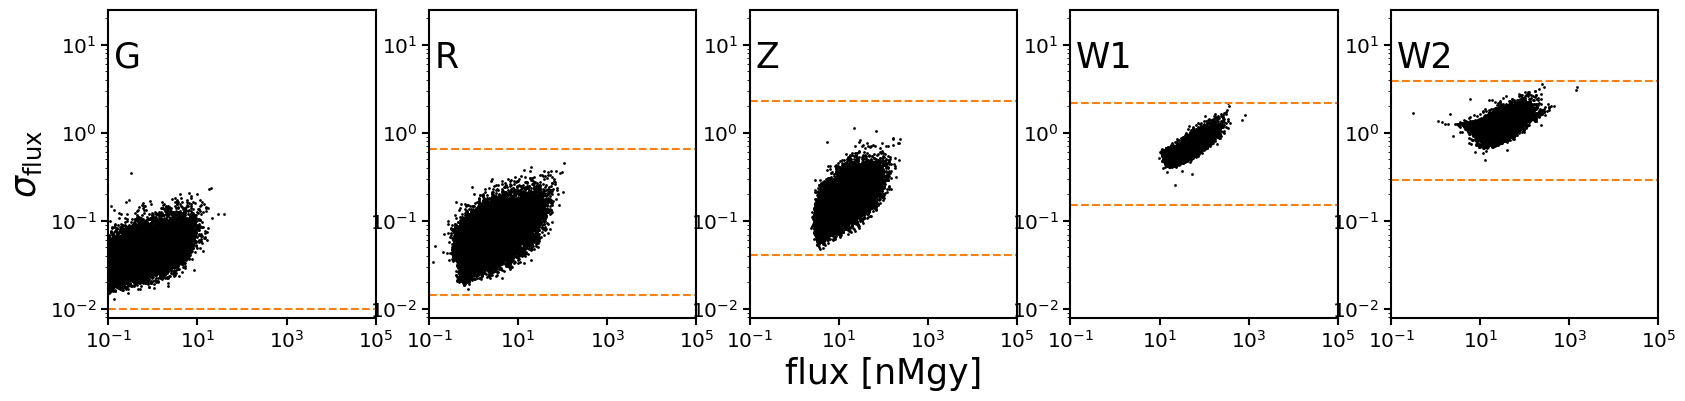

In [6]:
bands = ['G', 'R', 'Z', 'W1', 'W2']

fig = plt.figure(figsize=(20,4))

for i, band in enumerate(bands): 
    sub = fig.add_subplot(1,5,i+1)
    _mag = lrg['FLUX_%s' % band]
    _sig = lrg['FLUX_IVAR_%s' % band]**-0.5
    
    sub.scatter(_mag[::100], _sig[::100], s=1, c='k')
    
    _min, _max = np.quantile(_sig, (0., 0.99999))
    print('%.4f - %.4f' % (_min, _max))
    sub.axhline(_min, color='C1', linestyle='--')
    sub.axhline(_max, color='C1', linestyle='--')    
    
    sub.set_xlim(1e-1, 1e5)
    sub.set_xscale('log')
    if i == 2: sub.set_xlabel('flux [nMgy]', fontsize=25)

    sub.set_ylim(10**-2.1, 25)
    sub.set_yscale('log')
    if i == 0: sub.set_ylabel(r'$\sigma_{\rm flux}$', fontsize=25)
    
    sub.text(0.02, 0.9, band, ha='left', va='top', transform=sub.transAxes, fontsize=25)

/tmp/ipykernel_738490/1194048752.py:5: RuntimeWarning: divide by zero encountered in log10
  _mag = 22.5 - 2.5 * np.log10(lrg['FLUX_%s' % band])
/tmp/ipykernel_738490/1194048752.py:5: RuntimeWarning: invalid value encountered in log10
  _mag = 22.5 - 2.5 * np.log10(lrg['FLUX_%s' % band])
/tmp/ipykernel_738490/1194048752.py:6: RuntimeWarning: divide by zero encountered in power
  _sig = np.abs(-2.5 * (lrg['FLUX_IVAR_%s' % band]**-0.5)/lrg['FLUX_%s' % band]/np.log(10))


0.00073946815 inf
0.0004301492 3.0460258
0.00071565236 3.1028829
0.0007717042 0.08473389


/tmp/ipykernel_738490/1194048752.py:5: RuntimeWarning: invalid value encountered in log10
  _mag = 22.5 - 2.5 * np.log10(lrg['FLUX_%s' % band])


0.0010999624 447.04355


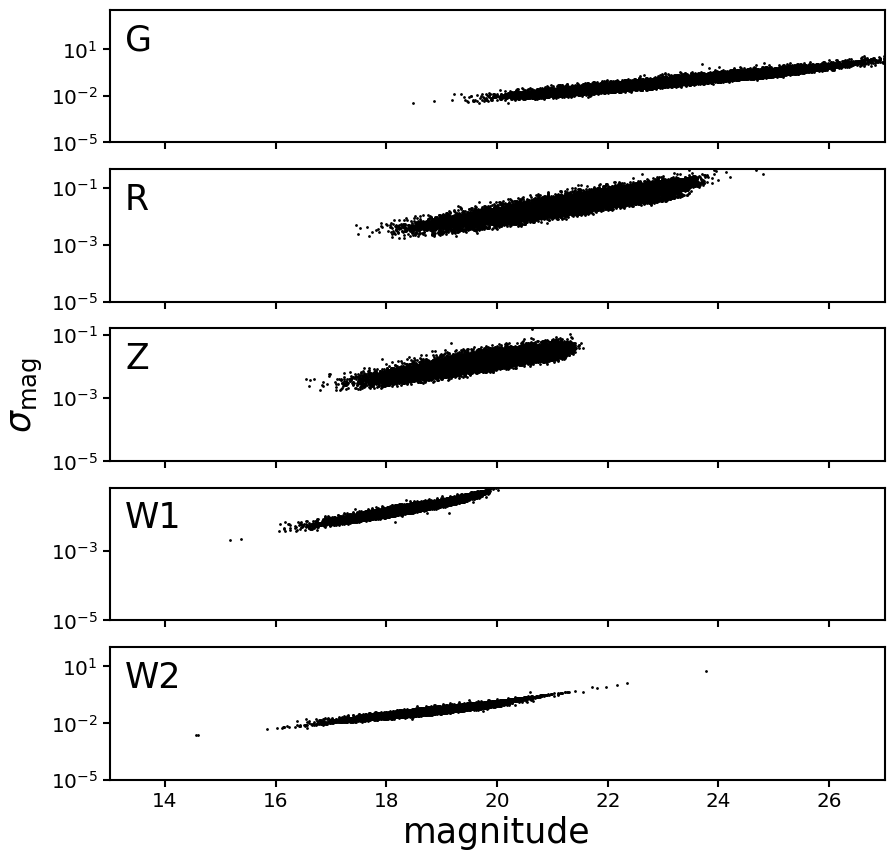

In [9]:
fig = plt.figure(figsize=(10,10))

for i, band in enumerate(bands): 
    sub = fig.add_subplot(5,1,i+1)
    _mag = 22.5 - 2.5 * np.log10(lrg['FLUX_%s' % band])
    _sig = np.abs(-2.5 * (lrg['FLUX_IVAR_%s' % band]**-0.5)/lrg['FLUX_%s' % band]/np.log(10))
    
    sub.scatter(_mag[::100], _sig[::100], s=1, c='k')
    sub.set_xlim(13, 27)
    if i == 4: sub.set_xlabel('magnitude', fontsize=25)
    else: sub.set_xticklabels([])
    print(_sig.min(), _sig.max())
    sub.set_ylim(1e-5, None)
    sub.set_yscale('log')
    if i == 2: sub.set_ylabel(r'$\sigma_{\rm mag}$', fontsize=25)
    
    sub.text(0.02, 0.9, band, ha='left', va='top', transform=sub.transAxes, fontsize=25)

/tmp/ipykernel_738490/2175632380.py:5: RuntimeWarning: divide by zero encountered in power
  _sig = lrg['FLUX_IVAR_%s' % band]**-0.5


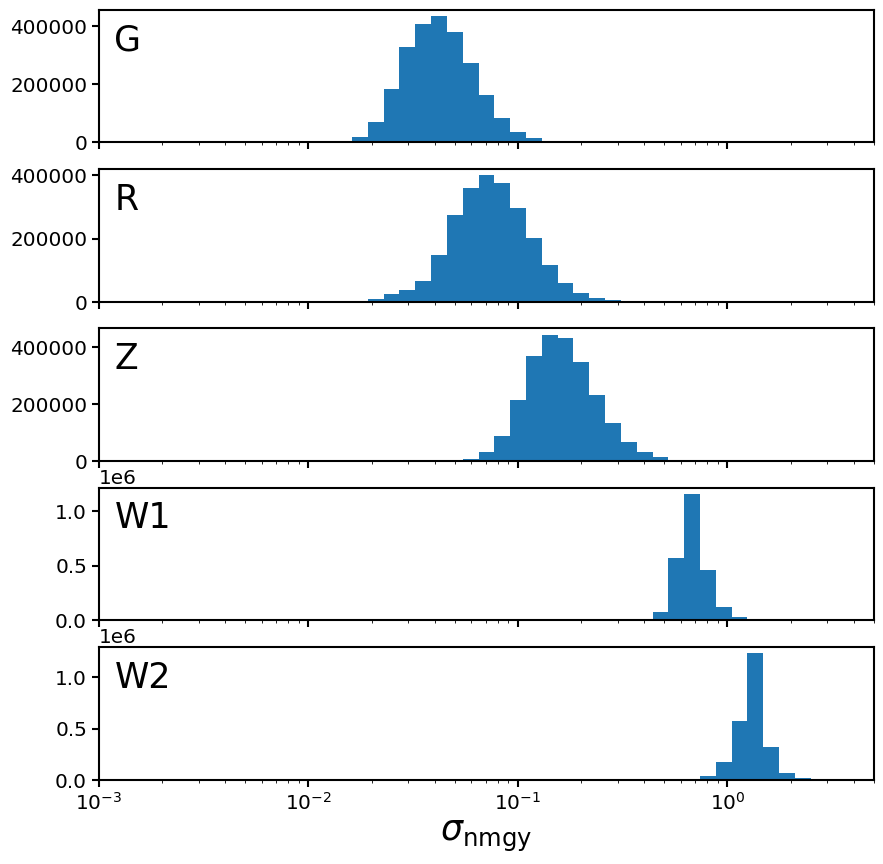

In [10]:
fig = plt.figure(figsize=(10,10))

for i, band in enumerate(bands): 
    sub = fig.add_subplot(5,1,i+1)
    _sig = lrg['FLUX_IVAR_%s' % band]**-0.5
    logbin = np.logspace(np.log10(1e-3), np.log10(5))
    sub.hist(_sig, bins=logbin)
    sub.set_xlim(1e-3, 5)
    sub.set_xscale('log')
    if i == 4: sub.set_xlabel(r'$\sigma_{\rm nmgy}$', fontsize=25)
    else: sub.set_xticklabels([])
    
    sub.text(0.02, 0.9, band, ha='left', va='top', transform=sub.transAxes, fontsize=25)